In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensures the output of transformers are pandas DataFrames for easier inspection
from sklearn import set_config
set_config(transform_output="pandas")

In [14]:
# Load dataset
df = pd.read_csv('tracks2026.csv')

# Step 1: Data Cleaning
df = df.dropna() # Remove missing values

# Step 2: Remove skewed data
# Filter out songs with popularity = 0 to prevent result skewing
df = df[df['popularity'] != 0]

# Step 3: Drop non-predictive columns and encode binary features
df = df.drop(columns=["track_id"])
map_cat = {False: 0, True: 1} # Logic from Classifier notebook[cite: 2]
df[['explicit']] = df[['explicit']].replace(map_cat)

# Define target and predictors
y = df['popularity']
X = df.drop(columns=['popularity'])

print(f"Dataset size after removing zero-popularity entries: {df.shape[0]}")

Dataset size after removing zero-popularity entries: 1538


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1230
Test set size: 308


In [16]:
# Identify columns based on distribution (Logic from Classifier notebook[cite: 2])
no_outlier_cols = ['valence', 'acousticness']
outlier_cols_neg = ['loudness']
outlier_cols_pos = ['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
key_timesignature_cols = ["key", "time_signature"]

# Define sub-pipelines for different feature types
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p)),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([('scaler', RobustScaler())])

preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p)),
     ('scaler', RobustScaler())
])

# Combine into a single preprocessor
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', StandardScaler(), key_timesignature_cols),
        ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False), ["track_genre"])
    ],
    remainder='passthrough'
)

In [17]:
# Bundle Preprocessing and Regressor
# This ensures that both are treated as one atomic unit during CV[cite: 1]
full_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('ttr', TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=42),
        func=np.log1p, 
        inverse_func=np.expm1)
    )
])

# Setup 10-fold Cross-Validation[cite: 1]
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

# Define Hyperparameters to tune
param_grid = {
    'ttr__regressor__n_estimators': [50, 100],
    'ttr__regressor__max_depth': [10, 20]
}

# Use GridSearchCV to find best params while preventing leakage via the pipeline[cite: 1]
grid_search = GridSearchCV(
    full_pipe, 
    param_grid, 
    scoring='r2', 
    cv=cv10, 
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print(f"Best Cross-Validated R2: {grid_search.best_score_:.4f}")

Best Cross-Validated R2: -0.1815


Final Test Set Performance:
R2 Score: -0.0452
MAE: 19.4829
RMSE: 23.8712


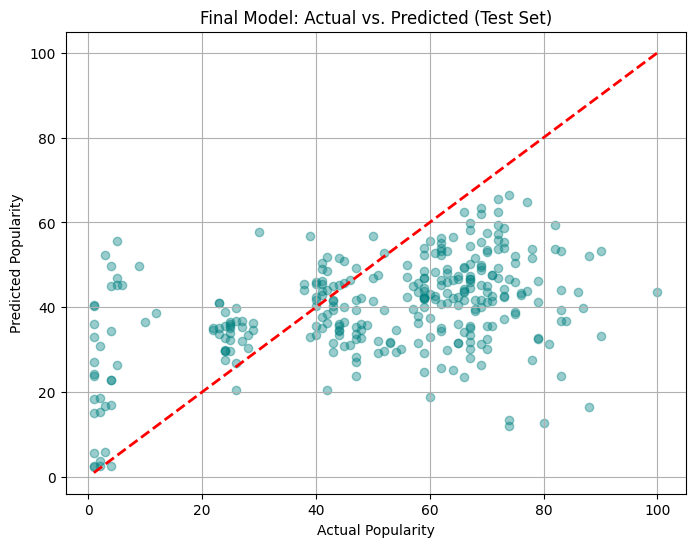

In [18]:
# Predict on the held-out test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calculate Metrics[cite: 1]
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final Test Set Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Visualization: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Final Model: Actual vs. Predicted (Test Set)")
plt.grid(True)
plt.show()